# Logistic Regression from Scratch

We’ll build a logistic regression model step by step using synthetic mouse data.  
The dataset includes **Weight (g)** and **Height (cm)**, and a binary target **Obese (1) or Healthy (0)**.  

## 1. What is Logistic Regression?
Logistic regression is a classification algorithm.  
It predicts the probability that an input belongs to a certain class (e.g., obese vs. not obese).  

The model equation is:

$$
P(y=1|x) = \sigma(w^T x + b)
$$

where:
- $w$ = weights (learnable parameters for each feature)
- $b$ = bias (learnable parameter)
- $\sigma(z) = \frac{1}{1+e^{-z}}$ = sigmoid function

---


## 2. Likelihood as Conditional Probability
Likelihood answers the question: *“Given my parameters $w$, how probable is it that I observe this dataset?”*

For binary classification:
- Each label $y_i$ is either 0 or 1.
- The probability of seeing $y_i$ given input $x_i$ is:

$$
P(y_i|x_i; w) = p_i^{y_i} (1-p_i)^{(1-y_i)}
$$

where $p_i = \sigma(w^T x_i)$.

The **likelihood of the whole dataset** is the product of all these probabilities:

$$
L(w) = \prod_{i=1}^n P(y_i|x_i; w)
$$

---



## 3. Log-Likelihood and Binary Cross Entropy
Multiplying many probabilities can get very small, so we take the log:

$$
\ell(w) = \sum_{i=1}^n \Big[ y_i \log(p_i) + (1-y_i)\log(1-p_i) \Big]
$$

- This is called the **log-likelihood**.
- **Maximum Likelihood Estimation (MLE)** means: find $w$ that maximizes $\ell(w)$.

Instead of maximizing, we minimize the **negative log-likelihood**:

$$
J(w) = -\ell(w)
$$

This is exactly the **Binary Cross Entropy Loss**:

$$
J(w) = -\frac{1}{n} \sum_{i=1}^n \Big[ y_i \log(p_i) + (1-y_i)\log(1-p_i) \Big]
$$

So: **minimizing binary cross entropy = maximizing likelihood.**

---


## 4. Gradient Descent and the Update Rule
To minimize the loss, we compute the gradient (derivative of loss wrt weights):

$$
\nabla J(w) = \frac{1}{n} X^T (h - y)
$$

This tells us how to adjust weights to reduce loss.

Update step:

$$
w \leftarrow w - \eta \cdot \nabla J(w)
$$

- $\eta$ = learning rate (step size).
- Each update moves weights closer to the values that maximize likelihood.
- Iteratively applying this update is how logistic regression learns.

---

In [34]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a seed for reproducibility
np.random.seed(100)

In [35]:
# Generate synthetic Mouse Data
n_samples = 100
weight = np.random.normal(30, 5, n_samples)
height = np.random.normal(10, 2, n_samples)

noise = np.random.normal(0, 2, n_samples)
condition = (weight + height + noise) > 42
target = condition.astype(int)


In [36]:
# Create DataFrame
df = pd.DataFrame({
    'Weight': weight,
    'Height': height,
    'Obese': target
})

# Quick look at the first 5 mice
print(df.head())

      Weight     Height  Obese
0  21.251173   6.590698      0
1  31.713402   7.727478      0
2  35.765179   4.053369      0
3  28.737820  10.066635      0
4  34.906604   9.502223      1


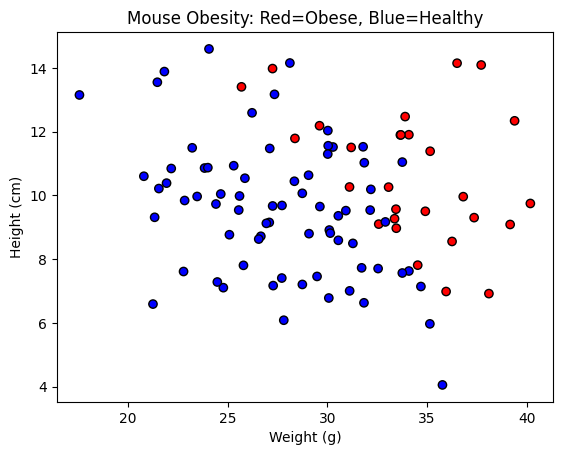

In [37]:
# Visualize the clusters
plt.scatter(df['Weight'], df['Height'], c=df['Obese'], cmap='bwr', edgecolors='k')
plt.xlabel('Weight (g)')
plt.ylabel('Height (cm)')
plt.title('Mouse Obesity: Red=Obese, Blue=Healthy')
plt.show()

## Preprocessing Data

Before training, we need to:
1. Extract features (Weight, Height) and target (Obese).
2. Standardize features so they’re on the same scale.
3. Add a bias term (column of ones) for the intercept.

In [38]:
def preprocess_data(df):
    # Extract features and target
    X = df[['Weight', 'Height']].values
    y = df['Obese'].values.reshape(-1, 1)

    # TODO: Standardize the features ( (X - mean) / std )
    X_scaled = X-np.mean(X)/np.std(X)

    # TODO: Add a column of ones to X for the bias term (np.hstack)
    #print(np.ones((X_scaled.shape[0],1)).shape)
    X_final = np.hstack((X_scaled,np.ones((X_scaled.shape[0],1))))

    return X_final, y

# Run the function
X_train, y_train = preprocess_data(df)
print(X_train)
print(y_train)

[[19.37792343  4.71744839  1.        ]
 [29.84015282  5.85422879  1.        ]
 [33.89192981  2.18011985  1.        ]
 [26.86457062  8.19338536  1.        ]
 [33.03335473  7.62897347  1.        ]
 [30.69784501  7.22639793  1.        ]
 [29.23264915  8.3916064   1.        ]
 [22.77653415  8.17117866  1.        ]
 [27.17927165  8.76148675  1.        ]
 [29.40175802  6.62192244  1.        ]
 [25.83661587  5.53396718  1.        ]
 [30.30256824  8.31702969  1.        ]
 [25.20877555  7.2793206   1.        ]
 [32.21098616  5.75478367  1.        ]
 [31.49035483  7.39582681  1.        ]
 [27.60469508  5.58470472  1.        ]
 [25.47034891 11.29909268  1.        ]
 [33.27541422  9.51353212  1.        ]
 [25.93607269  4.21058833  1.        ]
 [22.53515957  7.85714818  1.        ]
 [36.2216591   5.04551875  1.        ]
 [35.83477667 12.22017874  1.        ]
 [26.8673551   5.33275211  1.        ]
 [23.91457211  5.93240683  1.        ]
 [29.04934425  7.64932506  1.        ]
 [32.8121618   5.268617  

## Logistic Regression Implementation

We’ll implement logistic regression **from scratch**:
- Sigmoid function
- Binary Cross Entropy loss
- Gradient descent for weight updates


In [39]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, iters=1000):
        self.lr = lr
        self.iters = iters
        self.weights = None
        self.losses = []

    def sigmoid(self, z):
        # TODO: Implement sigmoid formula
        return 1/(1+np.exp(-z))
        #pass

    def compute_loss(self, y, h):
        # TODO: Implement Binary Cross Entropy Loss
        return -np.mean(y*np.log(h)+(1-y)*np.log(1-h))
        #pass

    def fit(self, X, y):
        # Initialize weights (size = number of features)
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))

        for i in range(self.iters):
            # 1. Forward Pass: Calculate z and h
            z=np.dot(X,self.weights)
            h=self.sigmoid(z)

            # 2. Compute Loss and append to self.losses
            loss=self.compute_loss(y,h)
            self.losses.append(loss)

            # 3. Calculate Gradient (dw)
            dw=(1/n_samples)*np.dot(X.T,(h-y))

            # 4. Update Weights
            self.weights-=self.lr*dw
            pass

    def predict(self, X):
        # TODO: Return 1 if sigmoid(Xw) > 0.5 else 0
        z=np.dot(X,self.weights)
        h=self.sigmoid(z)
        return(h>=0.5).astype(int)



## Training the Model

Now we’ll train our logistic regression model on the mouse dataset.  
We’ll also plot the **loss history** to check if the model is learning.


In [40]:
# 1. Complete the TODOs above.
# 2. Train the model using X_train, y_train.
# 3. Plot the 'Loss History' to see if it decreases over time.

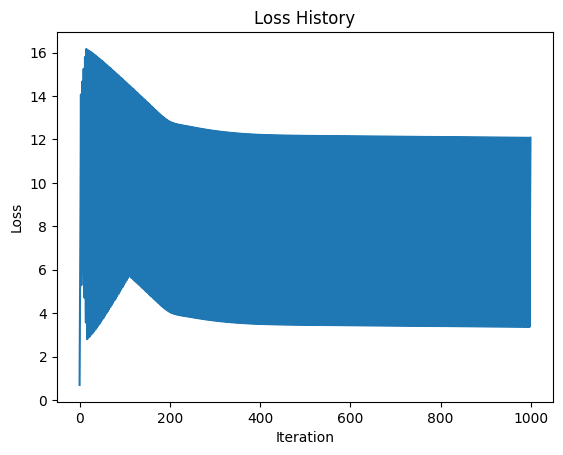

Training Accuracy: 0.7


In [41]:
# Train the model
model = LogisticRegressionScratch(lr=0.1, iters=1000)
model.fit(X_train, y_train)

# Plot loss history
plt.plot(model.losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss History")
plt.show()

# Predictions
y_pred = model.predict(X_train)

# Accuracy
accuracy = (y_pred == y_train).mean()
print("Training Accuracy:", accuracy)
